In [42]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
import pickle

In [43]:
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
# behaviors = ['inc', 'dec', 'flat']

n_vox=2000

event='10flies'

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [44]:
for file in os.listdir(later_dir):
    if event in file:
        print(file)
        behave_dict_path=os.path.join(later_dir,file)
        with open(behave_dict_path, 'rb') as file:
            behave_dict_total = pickle.load(file)
            behaviors=list(behave_dict_total.keys())
            print(f'behaviors are {list(behave_dict_total.keys())}')

behave_dict_total_10flies.pkl
behaviors are ['total', 'inc', 'dec', 'flat']


In [64]:
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies_nomask.npy'))

In [65]:
supervox_dict_total=brainsss.make_supervox_dict(behave_dict_total, behaviors, n_vox,giant_cluster_labels)

full_res={}
for behave in supervox_dict_total:
    print(behave)
    supervox_brain=np.moveaxis(supervox_dict_total[behave],-1,-2)
    full_res_brain=brainsss.supervoxel_to_full_res(supervox_brain, giant_cluster_labels, n_vox)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    full_res[behave]=np.asarray(full_res_brain)

total shape: (91, 2000, 24)
inc shape: (91, 2000, 24)
dec shape: (91, 2000, 24)
flat shape: (91, 2000, 24)
total
inc
dec
flat


In [66]:
print(giant_cluster_labels.shape)
print(behave_dict_total['inc'].shape)

(91, 45844)
(314, 146, 91, 24)


(91, 314, 146)


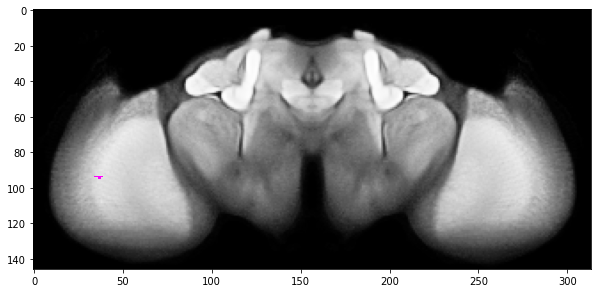

In [67]:
x,y,z,t=behave_dict_total['total'].shape
giant_labels_anat=giant_cluster_labels.reshape(-1,x,y)
print(giant_labels_anat.shape)
giant_labels_anat_sub=np.where(giant_labels_anat==1000,giant_labels_anat,np.nan)
# giant_labels_anat_sub[giant_labels_anat_sub!=0]=400

fixed = brainsss.load_fda_meanbrain().numpy()
fixed_rs=np.moveaxis(fixed,-1,0)

fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(fixed_rs[51].T,cmap='Greys_r')
ax.imshow(giant_labels_anat_sub[51].T,cmap='spring')


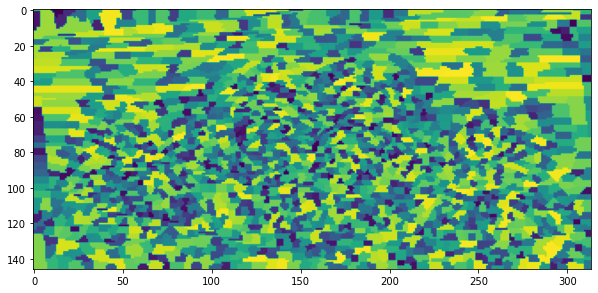

In [68]:
fig,axs=plt.subplots(figsize=(10,10))
axs.imshow(giant_labels_anat[77].T)
# img1=axs[1].imshow(check_brain.T,cmap='Greys')
# plt.colorbar(img)

(314, 146, 91, 24)


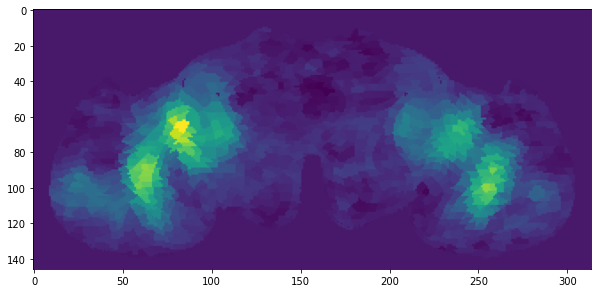

In [82]:
super_clust=500
brain=full_res['total']
brain=np.where(fixed[...,None]>0.1,brain, np.nan)
brain=np.nan_to_num(brain)
shape=np.shape(brain)
print(shape)
fig,axs=plt.subplots(figsize=(10,10))
axs.imshow(brain[...,51,15].T)

In [83]:
%%time
connectivity = grid_to_graph(shape[0],shape[1],shape[2]).astype('float32')
neural_activity= brain.reshape(-1, shape[-1])

cluster_labels_mask= []
cluster_model= AgglomerativeClustering(connectivity=connectivity,
                                       n_clusters=super_clust,
                                       memory=None,
                                       linkage='ward')

cluster_model.fit(neural_activity)
cluster_labels_mask = np.asarray(cluster_model.labels_)
print(f'shape of cluster labels {np.shape(cluster_labels)}')

shape of cluster labels (4171804,)
CPU times: user 17min 36s, sys: 17.6 s, total: 17min 53s
Wall time: 17min 53s


In [71]:
# %%time
# super_clust=500
# brain=full_res['total']
# # brain=np.where(fixed[...,None]>0.1,brain, -10000)
# shape=np.shape(brain)

# connectivity = grid_to_graph(shape[0],shape[1],shape[2]).astype('float32')
# neural_activity= brain.reshape(-1, shape[-1])

# cluster_labels= []
# cluster_model= AgglomerativeClustering(connectivity=connectivity,
#                                        n_clusters=super_clust,
#                                        memory=None,
#                                        linkage='ward')

# cluster_model.fit(neural_activity)
# cluster_labels = np.asarray(cluster_model.labels_)
# print(f'shape of cluster labels {np.shape(cluster_labels)}')

shape of cluster labels (4171804,)
CPU times: user 17min 23s, sys: 20.8 s, total: 17min 44s
Wall time: 17min 44s


In [86]:
# cluster_labels = np.asarray(cluster_labels_mask)
# save_file = os.path.join(cluster_dir, f'supercluster_labels_total_{super_clust}.npy')
# np.save(save_file,cluster_labels)
# print(np.shape(cluster_labels))

(4171804,)


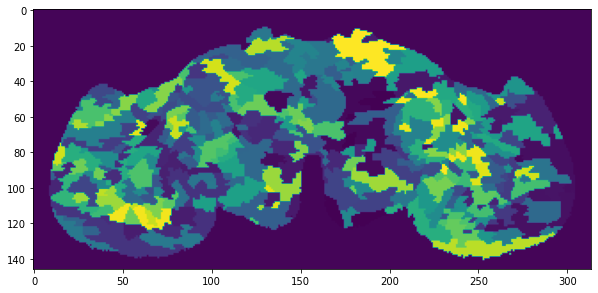

In [87]:
cluster_labels_anat=cluster_labels_mask.copy().reshape(314, 146, 91)
fig,axs=plt.subplots(figsize=(10,10))
axs.imshow(cluster_labels_anat[...,51].T)

In [8]:
def vox_to_full_res(labels, n_clust,behave_dict_path=None, supervox_dict=None):
    if supervox_dict==None:
        with open(behave_dict_path, 'rb') as file:
            behave_dict_total = pickle.load(file)
            behaviors=list(behave_dict_total.keys())
            print(f'behaviors are {list(behave_dict_total.keys())}')

        supervox_dict_total=brainsss.make_supervox_dict(behave_dict_total, behaviors, n_clust,labels)
    else:
        supervox_dict_total=supervox_dict

    full_res={}
    for behave in supervox_dict_total:
        supervox_brain=np.moveaxis(supervox_dict_total[behave],-1,-2)
        full_res_brain=brainsss.supervoxel_to_full_res(supervox_brain, labels, n_clust)
        full_res_brain=np.moveaxis(full_res_brain, 0,-1)
        full_res_brain=np.moveaxis(full_res_brain, 0,-1)
        full_res[behave]=np.asarray(full_res_brain)
    return full_res

In [9]:
event='best'
behave_dict_path=os.path.join(later_dir,f'behave_dict_total_{event}.pkl')
giant_vox_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))
full_res = sta_to_full_res(giant_vox_labels, n_vox, behave_dict_path)

NameError: name 'sta_to_full_res' is not defined

In [ ]:
super_clust=500
superclust_dict = {}
for behavior in full_res:
    brain=full_res[behavior]
    neural_activity= brain.reshape(-1, np.shape(brain)[-1])

    behavior_superclusters = []
    for cluster_num in range(super_clust):
        labels= cluster_labels
        cluster_indicies= np.where(labels==cluster_num)[0]
        mean_signal = np.mean(neural_activity[cluster_indicies,:], axis=0)
        behavior_superclusters.append(mean_signal)
    superclust_dict[behavior] = np.asarray(behavior_superclusters)

In [ ]:
superclust_dict['inc'].shape

In [ ]:
superclust_dict_z={}
for behavior in superclust_dict:
    print(behavior)
    signals_total_z=scipy.stats.zscore(superclust_dict[behavior],axis=1)
    superclust_dict_z[behavior]=signals_total_z

In [ ]:
full_res_superclust={}
print(super_clust)
cluster_brain=superclust_dict
behaviors=list(cluster_brain.keys())
for behave in behaviors:
    brain=cluster_brain[behave].T
    cluster_labels=cluster_labels.T
    n_tp = brain.shape[0]
    n_clusters = brain.shape[1]
    brain_dims=[314,146,91]
    
    colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]*brain_dims[2]))
    print(behave)
    colored_by_betas = brain[:, cluster_labels]  # Shape: (n_tp, n_voxels)
    colored_by_betas = colored_by_betas.reshape(n_tp, brain_dims[0], brain_dims[1], brain_dims[2])
    colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1],brain_dims[2])
    full_res_superclust[behave]=np.asarray(colored_by_betas)

In [ ]:
atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [ ]:
def explode_plot(brain,tp,vmax,explosion_rois,roi_masks,roi_contours,cmap='seismic'):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    data_to_plot = brain[tp][:,:,::-1]
    vmax =vmax #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap=cmap, diverging=True)#'hot')
    return explosion_map

In [ ]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

top_color=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7'])[::-1]
bottom=np.asarray(['#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
top_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'top_half_spect', top_color)
bottom_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'bottom_half_spect', bottom)

# Register the new colormap
plt.register_cmap(cmap=top_half_spect)
plt.register_cmap(cmap=bottom_half_spect)

In [ ]:
tp=2
vmax=0.05
ex_f=explode_plot(full_res_superclust['flat'],tp,vmax,explosion_rois,roi_masks,roi_contours, cmap_personal)
ex_i=explode_plot(full_res_superclust['inc'],tp,vmax,explosion_rois,roi_masks,roi_contours, cmap_personal)
ex_d=explode_plot(full_res_superclust['dec'],tp,vmax,explosion_rois,roi_masks,roi_contours, cmap_personal)


In [ ]:
ax_as=1.5
fig,axs=plt.subplots(1,3,figsize=(50,50))
axs[0].imshow(ex_i[170:,:]) #this was made with cmap=hot
axs[0].axis('off')
axs[0].set_title('inc',fontsize=50)
axs[0].set_aspect(ax_as)
axs[1].imshow(ex_d[170:,:]) #this was made with cmap=hot
axs[1].axis('off')
axs[1].set_title('dec',fontsize=50)
axs[1].set_aspect(ax_as)
axs[2].imshow(ex_f[170:,:]) #this was made with cmap=hot
axs[2].axis('off')
axs[2].set_title('flat',fontsize=50)
axs[2].set_aspect(ax_as)